# for mean file

     [Mean] Complete Feature Metrics (Sorted by R2)       
            Feature  RF_Importance  Correlation (r)  R2_Score
              B4/B5       0.154662        -0.720176  0.518654
    (B4-B5)/(B4+B5)       0.107488        -0.715760  0.512312
              B5/B4       0.084036         0.706705  0.499432
              B2/B5       0.069560        -0.673882  0.454117
    (B2-B5)/(B2+B5)       0.050037        -0.661420  0.437476
    (B3-B5)/(B3+B5)       0.011931        -0.659296  0.434671
              B5/B3       0.018831         0.657510  0.432319
              B3/B5       0.020703        -0.647976  0.419873
              B5/B2       0.050991         0.633499  0.401321
    (B2-B7)/(B2+B7)       0.006594        -0.410977  0.168902
    (B2-B6)/(B2+B6)       0.000609        -0.363558  0.132174
              B2/B4       0.000947        -0.362210  0.131196
    (B2-B4)/(B2+B4)       0.002696        -0.343592  0.118056
              B2/B7       0.004198        -0.337112  0.113644
           

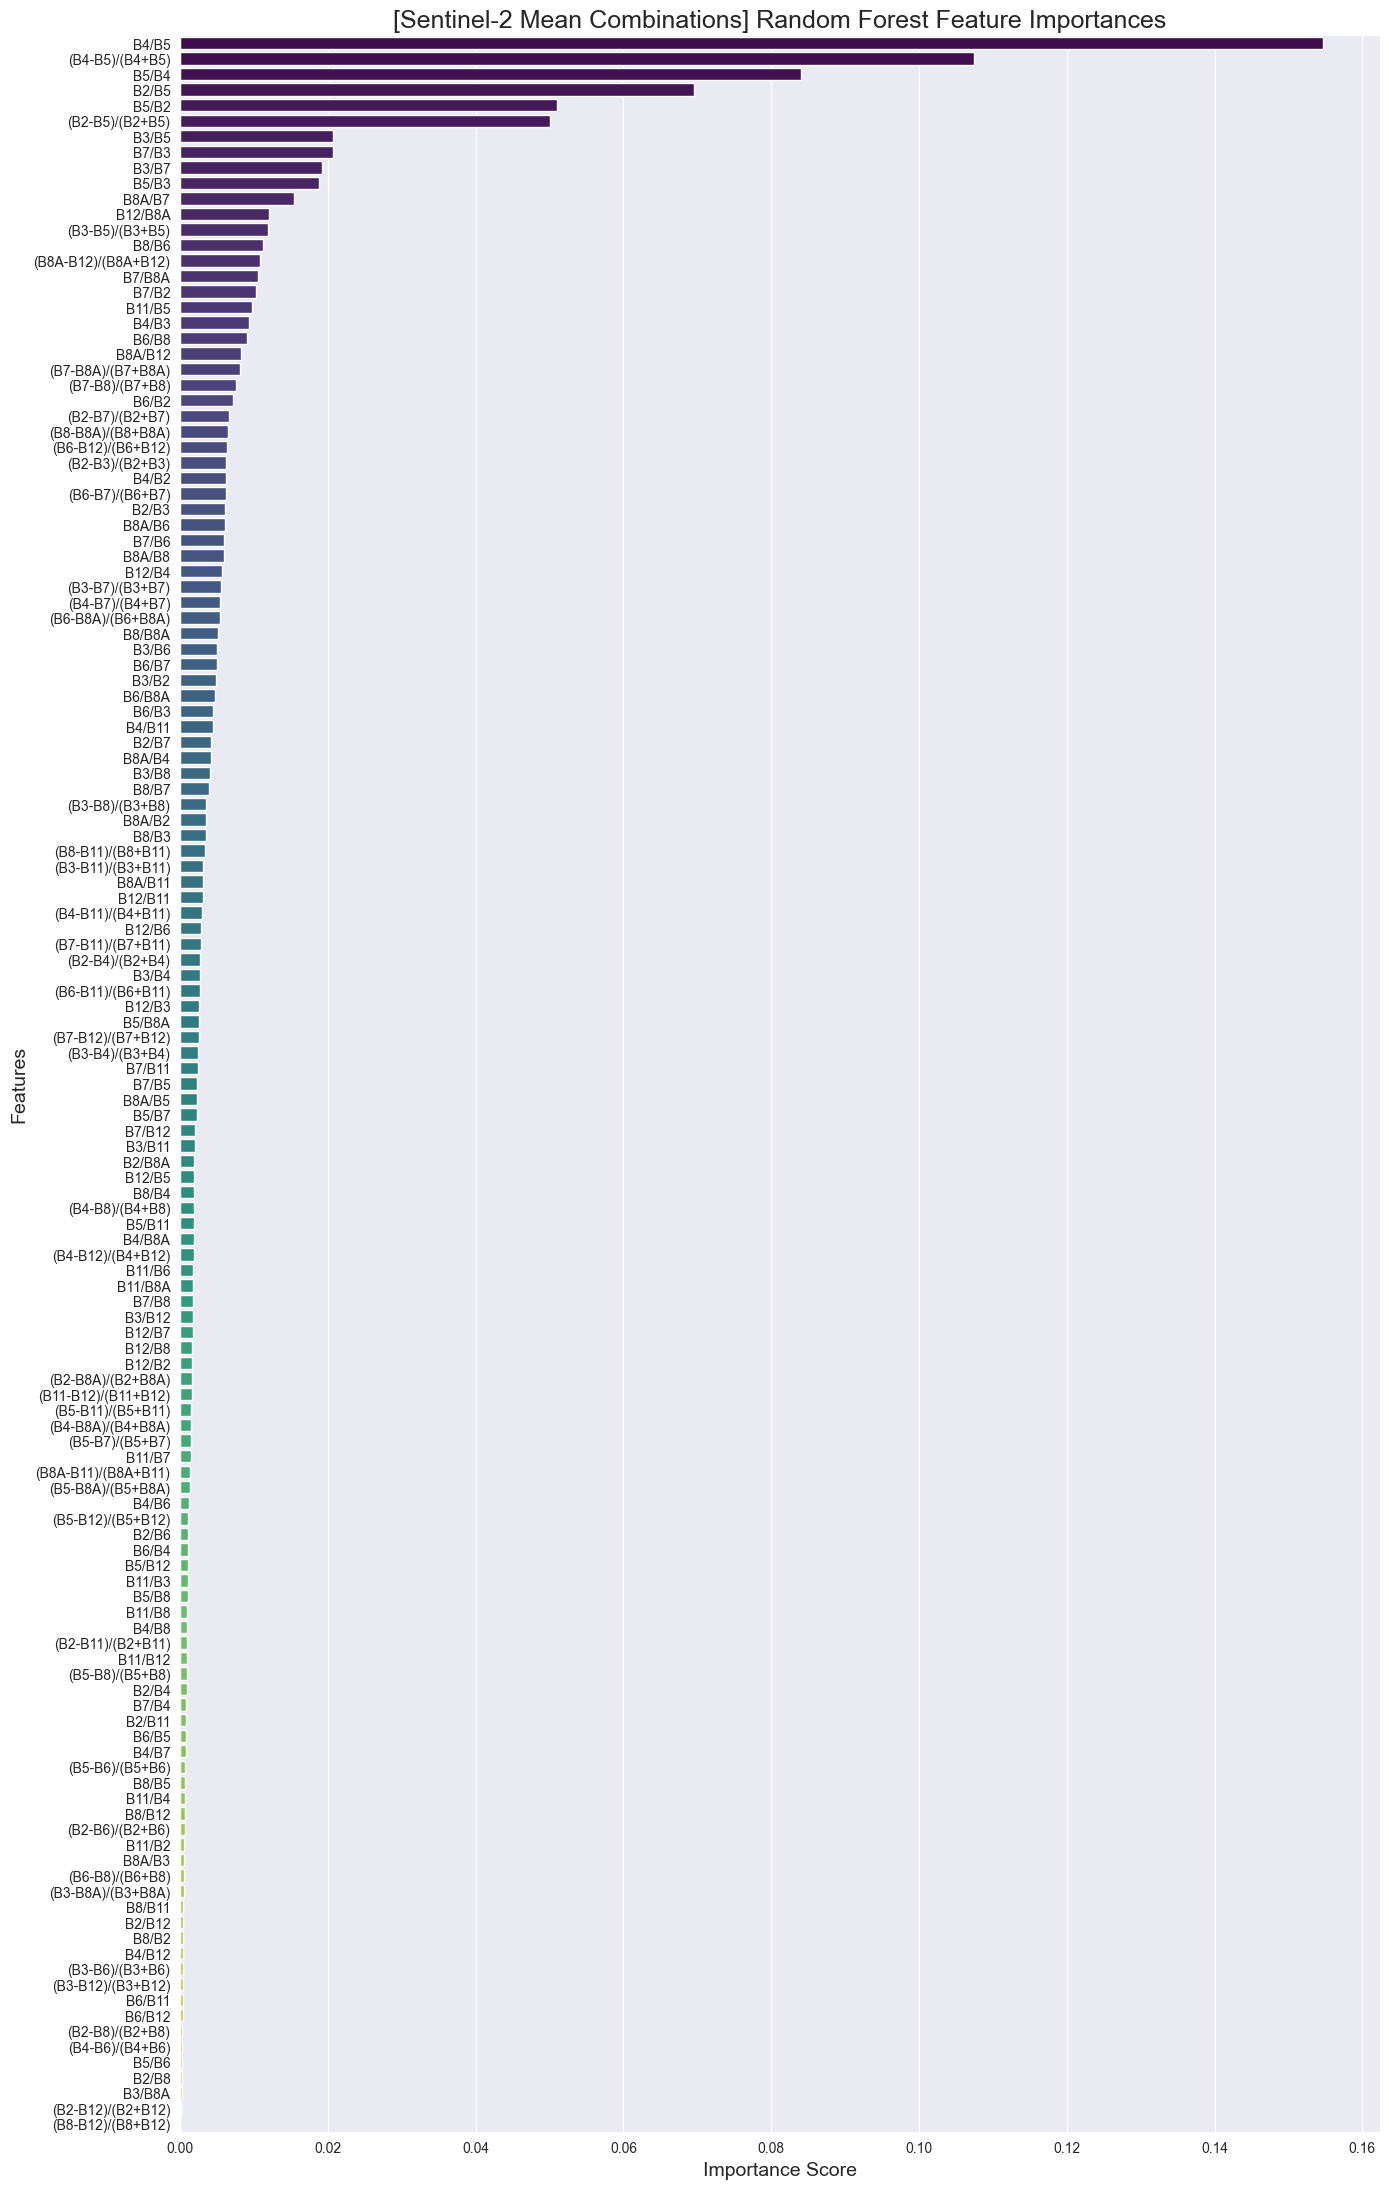

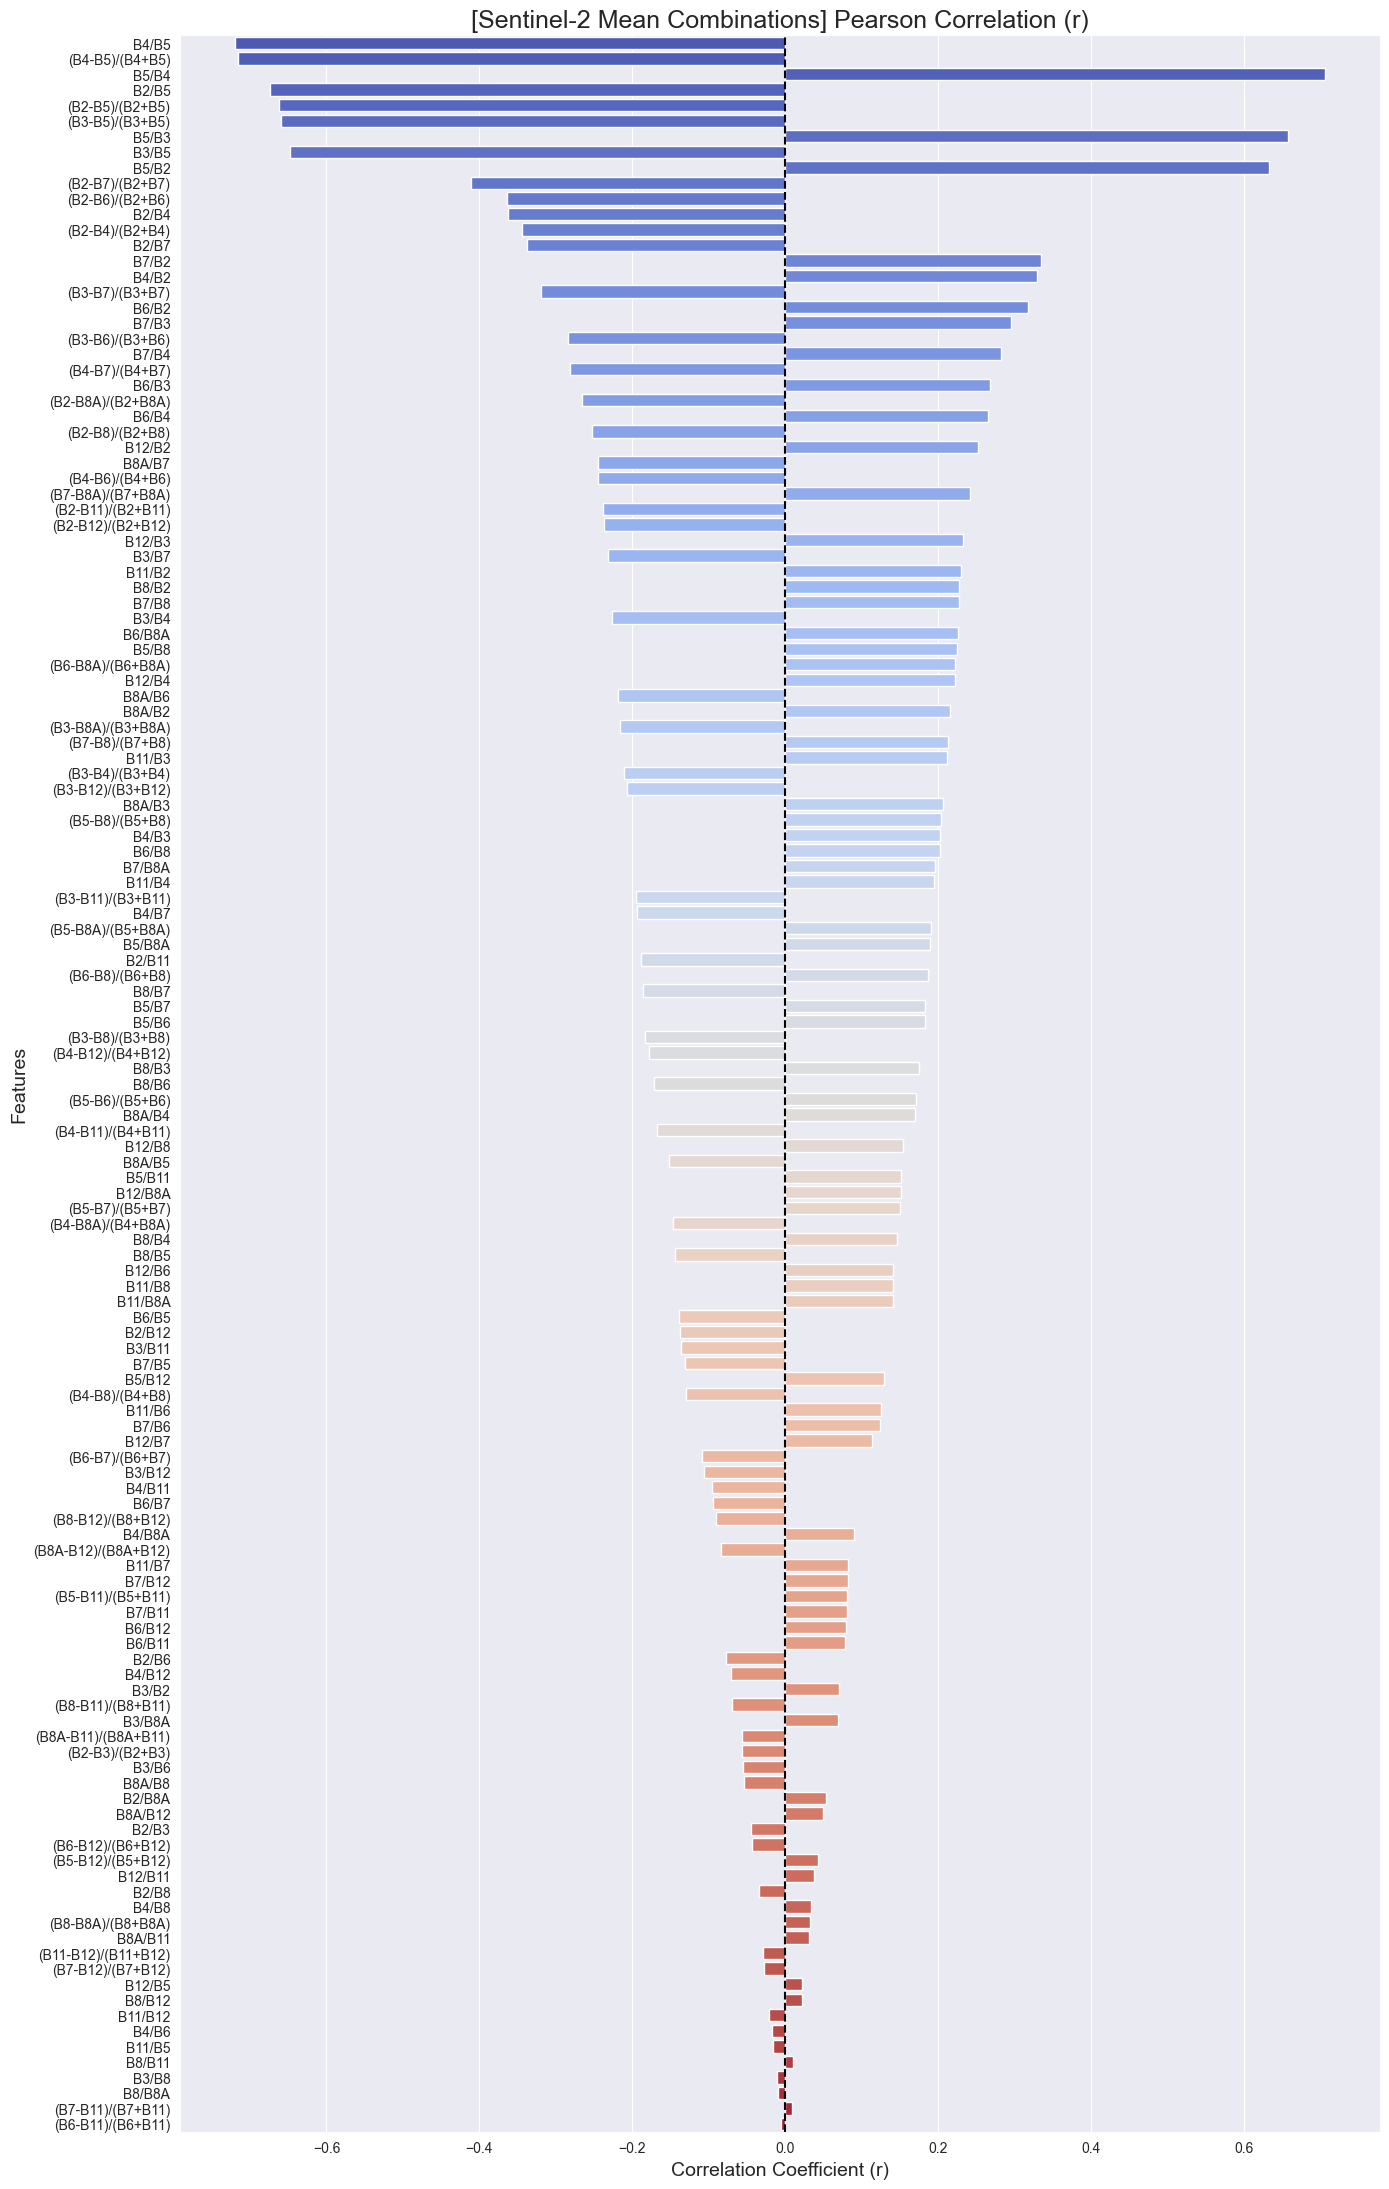

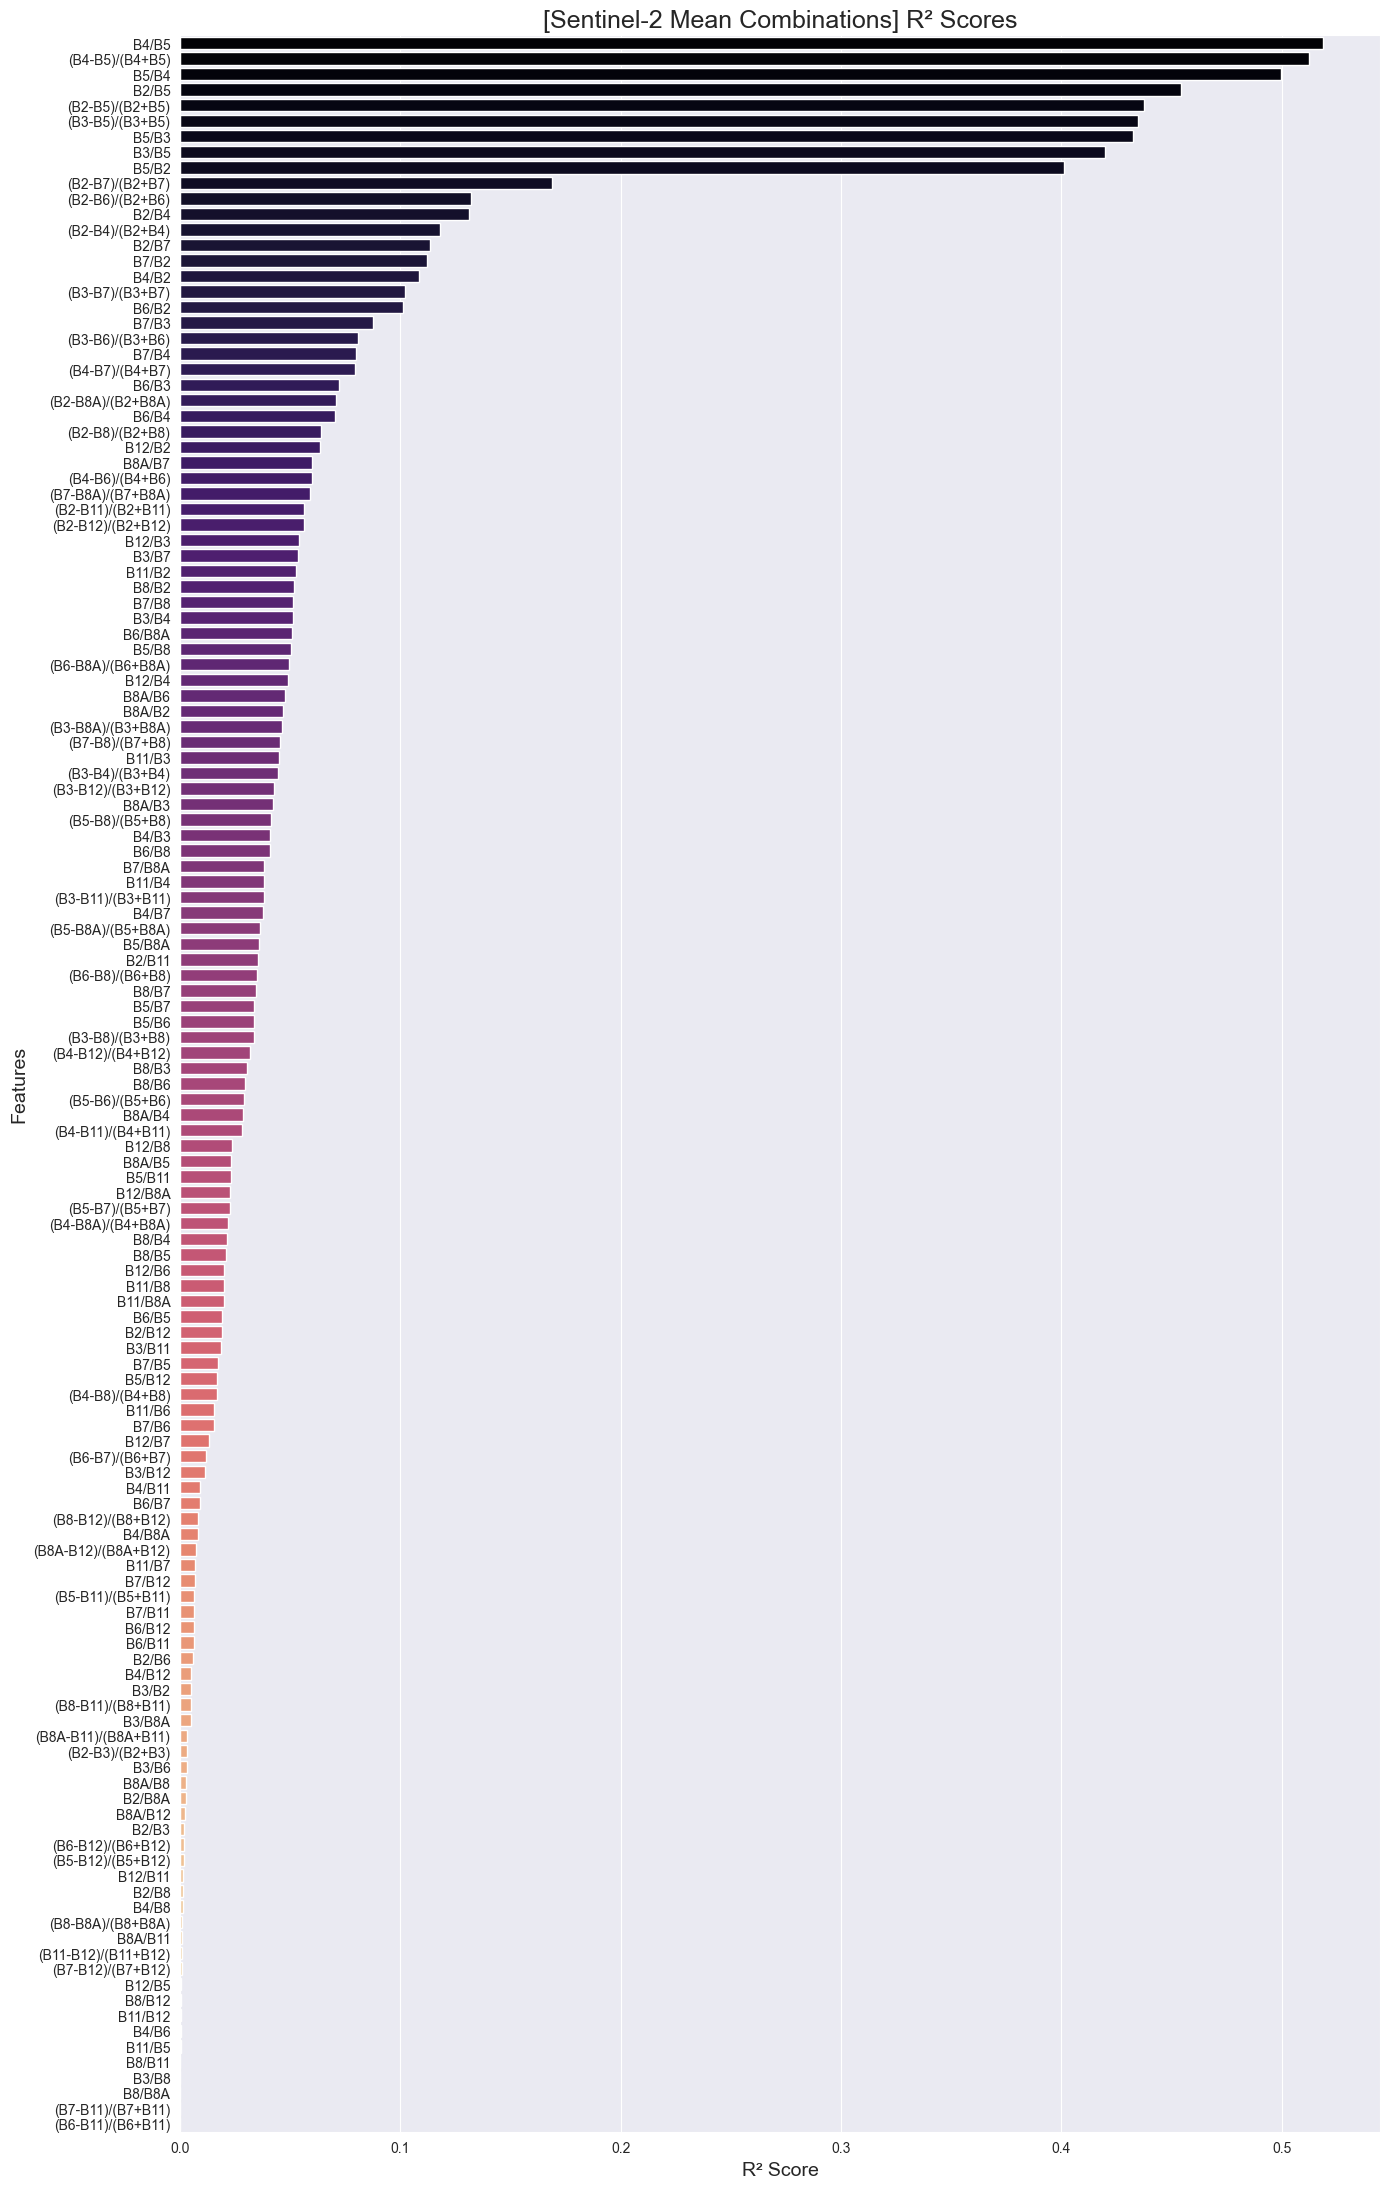

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# --- 1. Load Data ---
file_path = "Sentinel2_2024_Combinations(Mean_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
# Automatically find all ratio/combination columns (they all contain '/')
feature_cols = [col for col in df.columns if '/' in col and 'Unnamed' not in col]

data = df[[target_col] + feature_cols].dropna()
X = data[feature_cols]
y = data[target_col]

# --- 3. Calculate Metrics ---
# Random Forest Importance
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = rf.feature_importances_

# Pearson Correlation and R2 Score
correlations = X.apply(lambda col: col.corr(y))
r2_scores = correlations ** 2

# Combine into one DataFrame and sort by R2 Score
results_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': importances,
    'Correlation (r)': correlations,
    'R2_Score': r2_scores
}).sort_values(by='R2_Score', ascending=False)

# Print the complete list of values
print("==========================================================")
print("     [Mean] Complete Feature Metrics (Sorted by R2)       ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting (Separate, Full Width) ---

# Plot 1: Random Forest Feature Importance
plt.figure(figsize=(14, 22)) # Taller figure due to more combinations
rf_sorted = results_df.sort_values(by='RF_Importance', ascending=False)
sns.barplot(x='RF_Importance', y='Feature', data=rf_sorted, palette='viridis', hue='Feature', legend=False)
plt.title('[Sentinel-2 Mean Combinations] Random Forest Feature Importances', fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Pearson Correlation
plt.figure(figsize=(14, 22))
corr_sorted = results_df.sort_values(by='Correlation (r)', key=abs, ascending=False)
sns.barplot(x='Correlation (r)', y='Feature', data=corr_sorted, palette='coolwarm', hue='Feature', legend=False)
plt.title('[Sentinel-2 Mean Combinations] Pearson Correlation (r)', fontsize=18)
plt.xlabel('Correlation Coefficient (r)', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Plot 3: R2 Score
plt.figure(figsize=(14, 22))
r2_sorted = results_df.sort_values(by='R2_Score', ascending=False)
sns.barplot(x='R2_Score', y='Feature', data=r2_sorted, palette='magma', hue='Feature', legend=False)
plt.title('[Sentinel-2 Mean Combinations] R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# for median file

    [Median] Complete Feature Metrics (Sorted by R2)      
            Feature  RF_Importance  Correlation (r)  R2_Score
    (B4-B5)/(B4+B5)       0.118498        -0.747931  0.559401
              B4/B5       0.111176        -0.746771  0.557667
              B5/B4       0.116490         0.743683  0.553065
              B2/B5       0.076848        -0.678307  0.460101
    (B2-B5)/(B2+B5)       0.052112        -0.665476  0.442858
    (B3-B5)/(B3+B5)       0.013122        -0.645995  0.417310
              B3/B5       0.005392        -0.641238  0.411186
              B5/B3       0.009324         0.638477  0.407653
              B5/B2       0.077662         0.634332  0.402378
    (B2-B7)/(B2+B7)       0.003586        -0.380364  0.144676
              B2/B4       0.003774        -0.339060  0.114962
    (B2-B6)/(B2+B6)       0.006113        -0.328418  0.107858
              B2/B7       0.001911        -0.326518  0.106614
    (B2-B4)/(B2+B4)       0.004326        -0.314188  0.098714
           

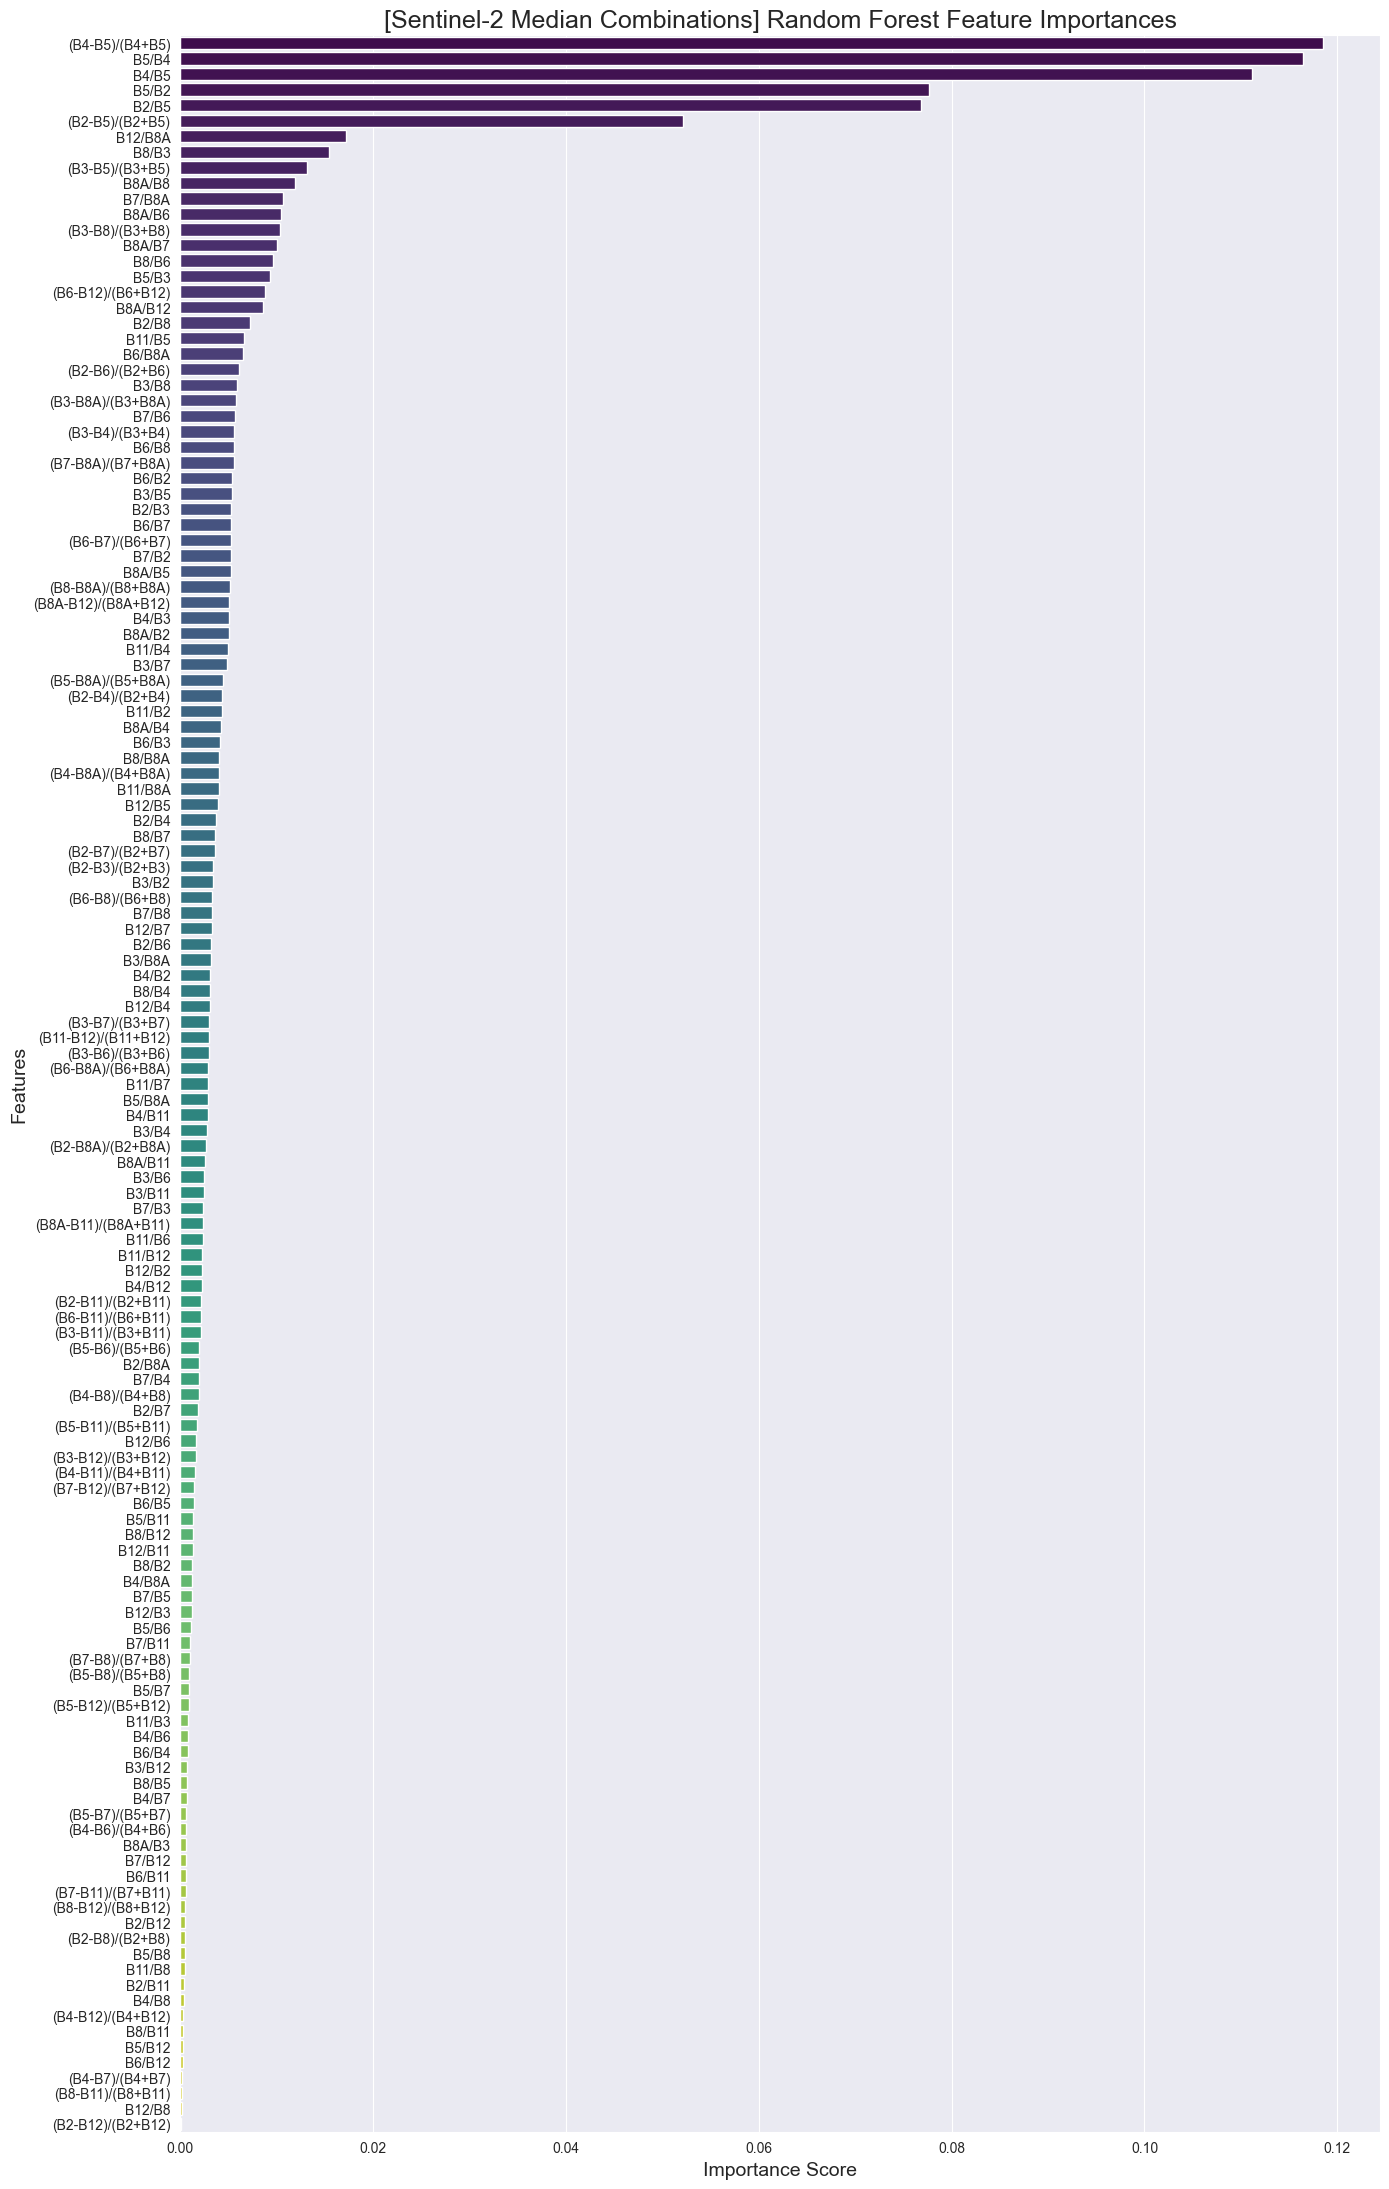

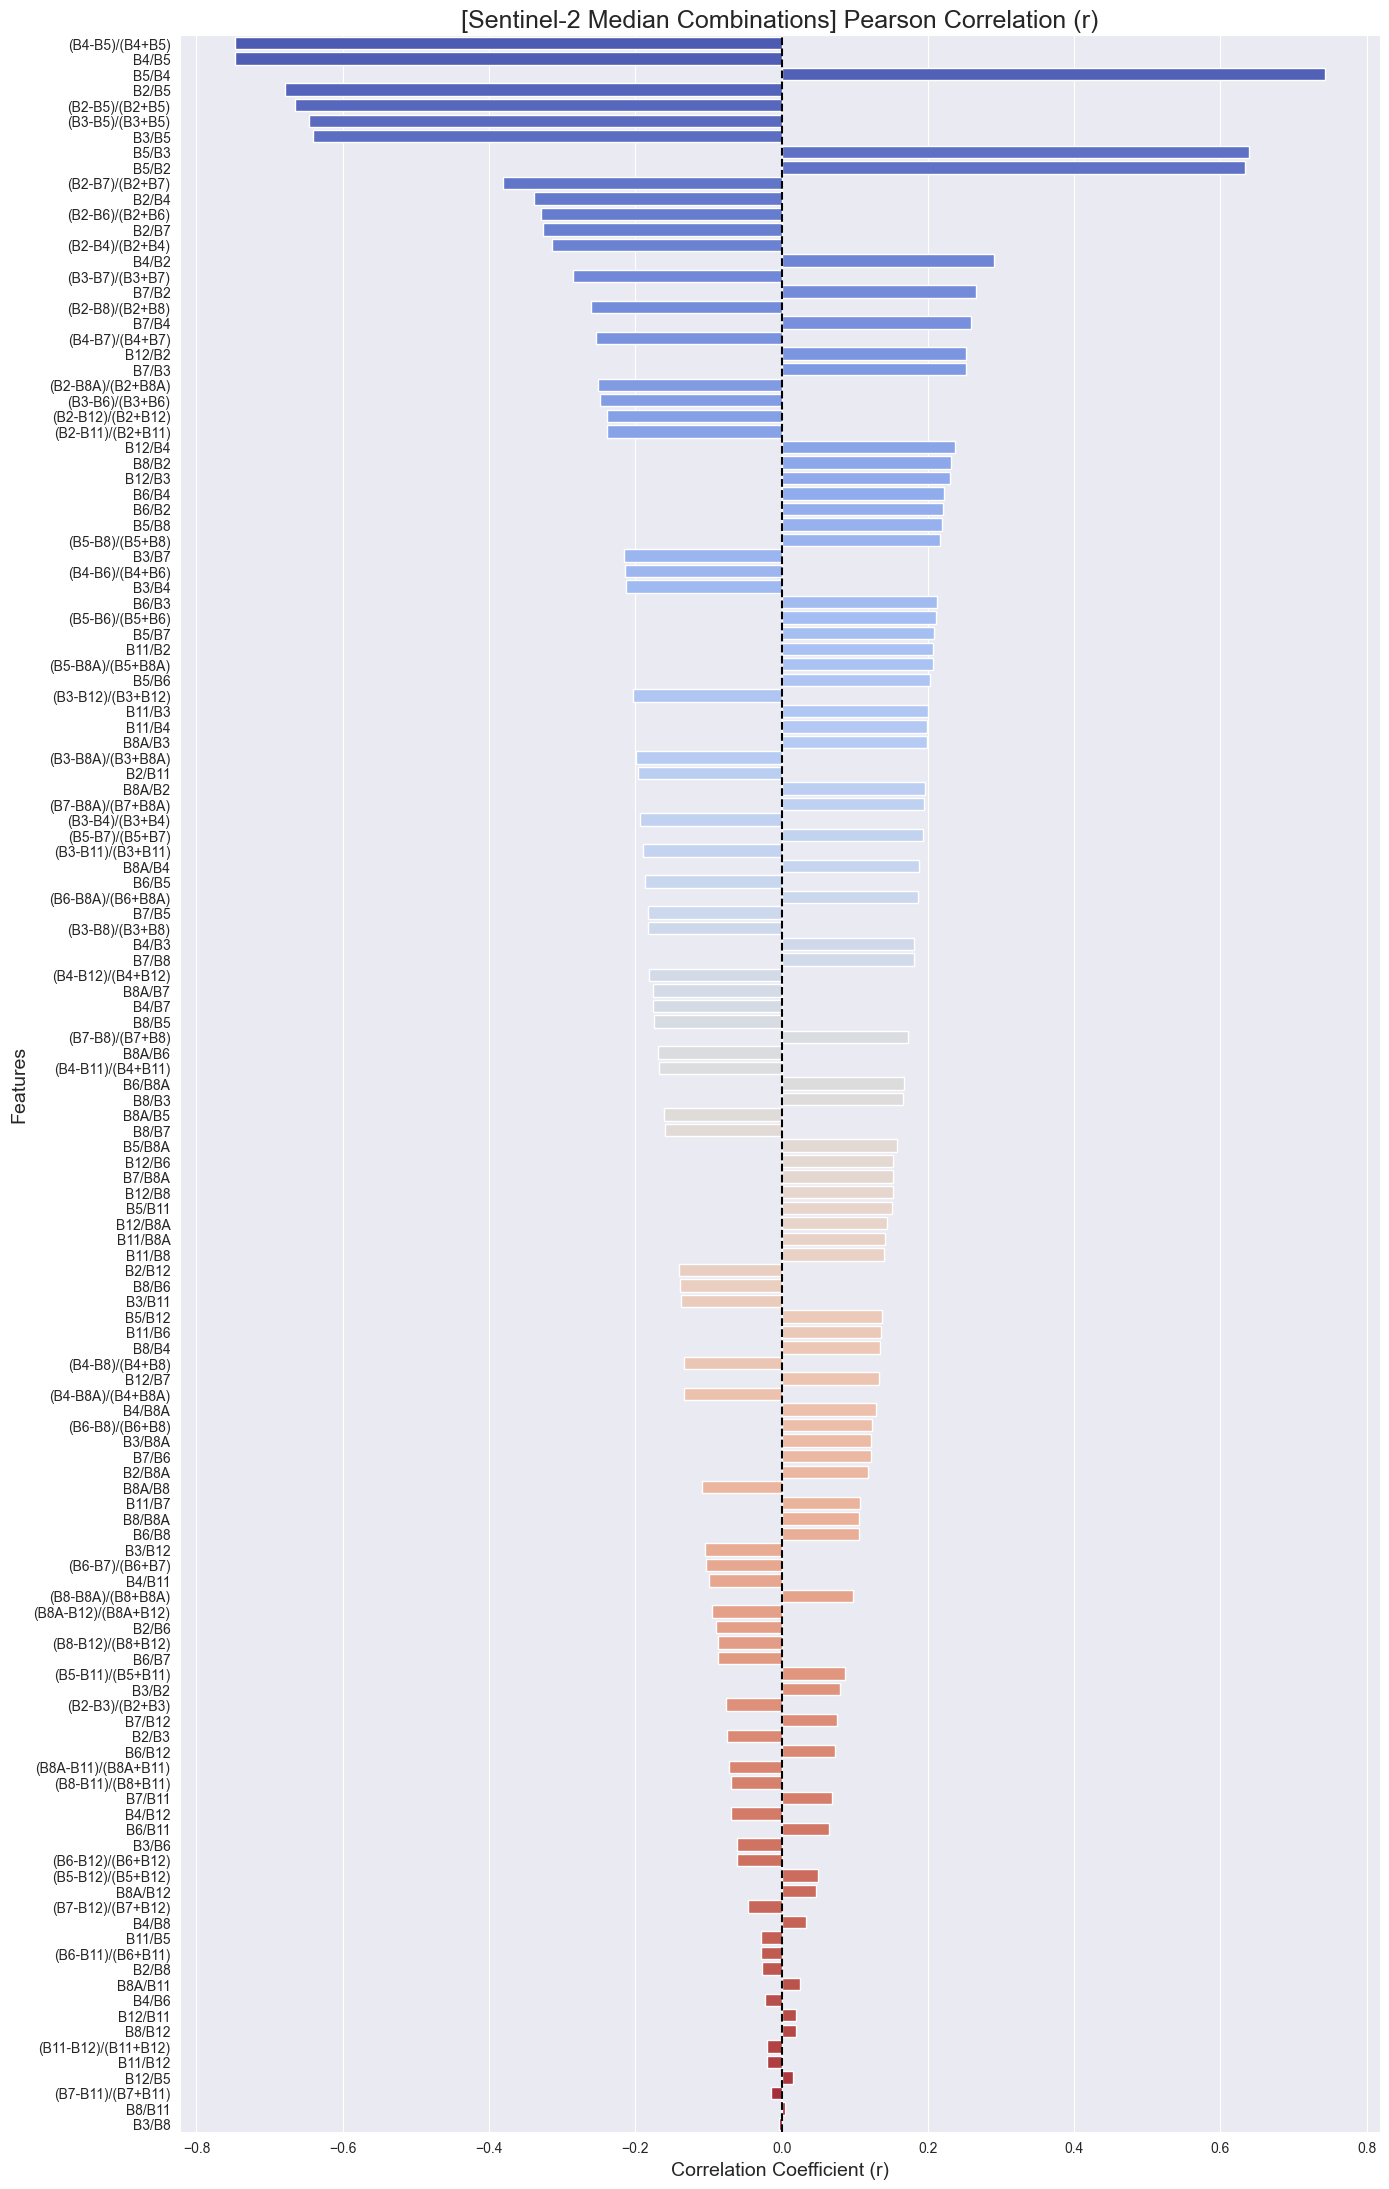

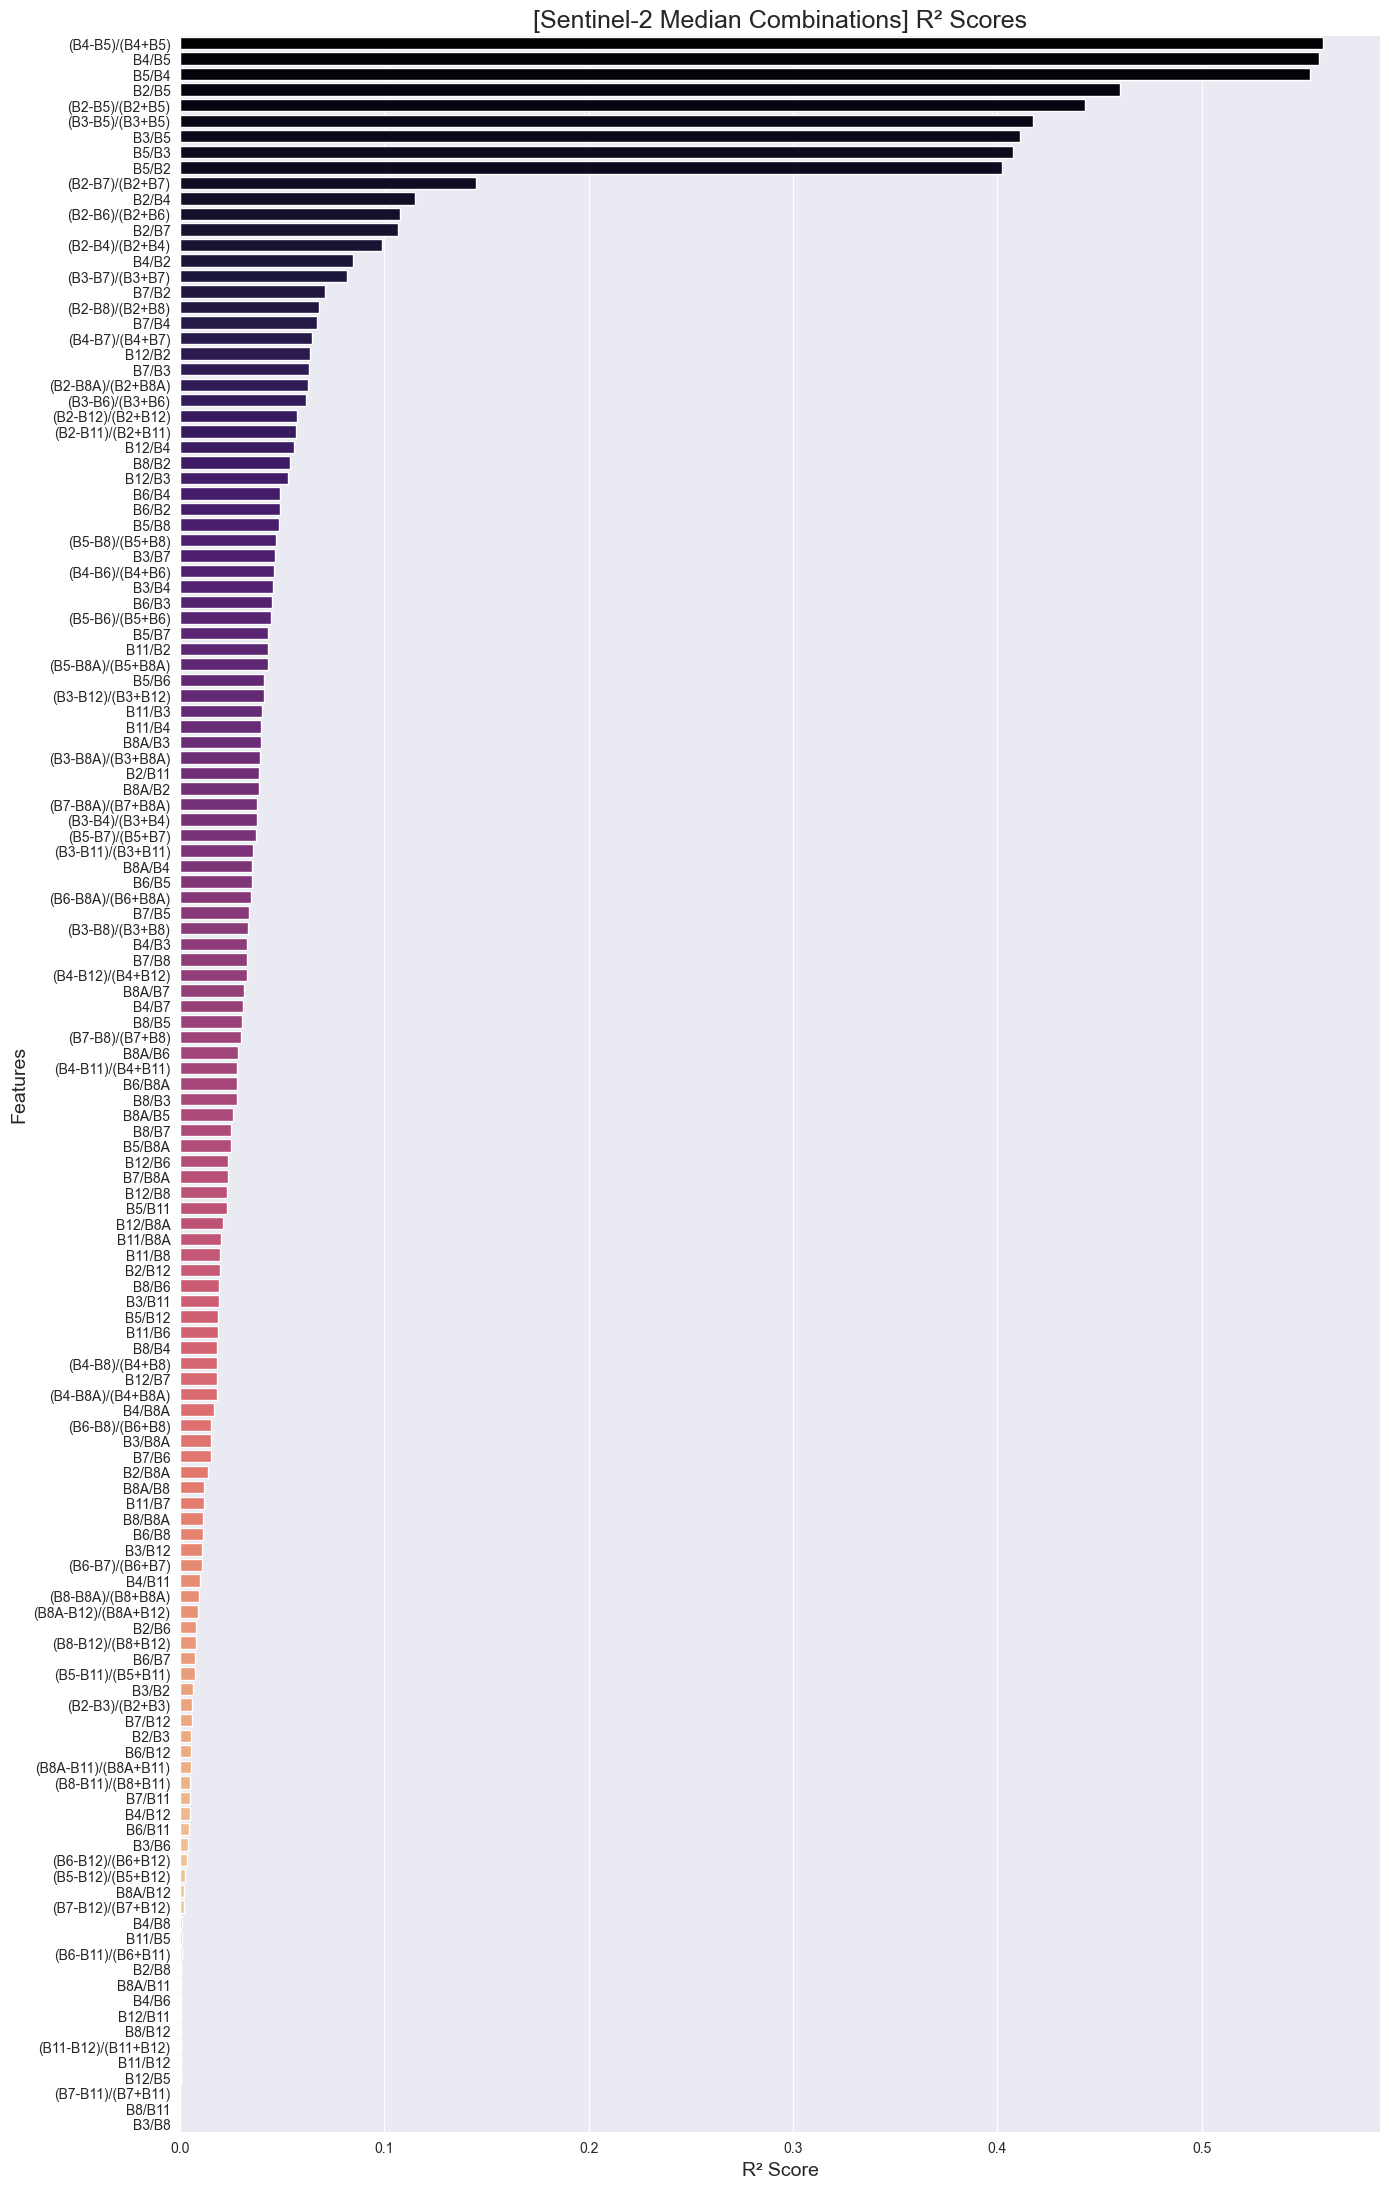

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# --- 1. Load Data ---
file_path = "Sentinel2_2024_Combinations(Median_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
feature_cols = [col for col in df.columns if '/' in col and 'Unnamed' not in col]

data = df[[target_col] + feature_cols].dropna()
X = data[feature_cols]
y = data[target_col]

# --- 3. Calculate Metrics ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = rf.feature_importances_

correlations = X.apply(lambda col: col.corr(y))
r2_scores = correlations ** 2

results_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': importances,
    'Correlation (r)': correlations,
    'R2_Score': r2_scores
}).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("    [Median] Complete Feature Metrics (Sorted by R2)      ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting (Separate, Full Width) ---

# Plot 1: RF Importance
plt.figure(figsize=(14, 22))
rf_sorted = results_df.sort_values(by='RF_Importance', ascending=False)
sns.barplot(x='RF_Importance', y='Feature', data=rf_sorted, palette='viridis', hue='Feature', legend=False)
plt.title('[Sentinel-2 Median Combinations] Random Forest Feature Importances', fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Correlation
plt.figure(figsize=(14, 22))
corr_sorted = results_df.sort_values(by='Correlation (r)', key=abs, ascending=False)
sns.barplot(x='Correlation (r)', y='Feature', data=corr_sorted, palette='coolwarm', hue='Feature', legend=False)
plt.title('[Sentinel-2 Median Combinations] Pearson Correlation (r)', fontsize=18)
plt.xlabel('Correlation Coefficient (r)', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Plot 3: R2 Score
plt.figure(figsize=(14, 22))
r2_sorted = results_df.sort_values(by='R2_Score', ascending=False)
sns.barplot(x='R2_Score', y='Feature', data=r2_sorted, palette='magma', hue='Feature', legend=False)
plt.title('[Sentinel-2 Median Combinations] R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# for sd file

      [SD] Complete Feature Metrics (Sorted by R2)        
        Feature  RF_Importance  Correlation (r)  R2_Score
          B4/B3       0.075455        -0.173025  0.029938
(B3-B4)/(B3+B4)       0.032820         0.151644  0.022996
          B4/B2       0.069204        -0.146752  0.021536
          B3/B8       0.030466         0.139205  0.019378
          B2/B3       0.086586        -0.118509  0.014044
          B2/B8       0.035235         0.117497  0.013806
          B8/B2       0.067105        -0.114757  0.013169
(B3-B8)/(B3+B8)       0.038778         0.111994  0.012543
          B8/B3       0.045742        -0.111346  0.012398
(B2-B4)/(B2+B4)       0.039829         0.097866  0.009578
          B3/B4       0.053251         0.096723  0.009355
(B2-B8)/(B2+B8)       0.042544         0.090701  0.008227
          B4/B8       0.032471         0.086256  0.007440
(B4-B8)/(B4+B8)       0.051183         0.054633  0.002985
          B8/B4       0.078813        -0.049402  0.002441
(B2-B3)/(B2+B

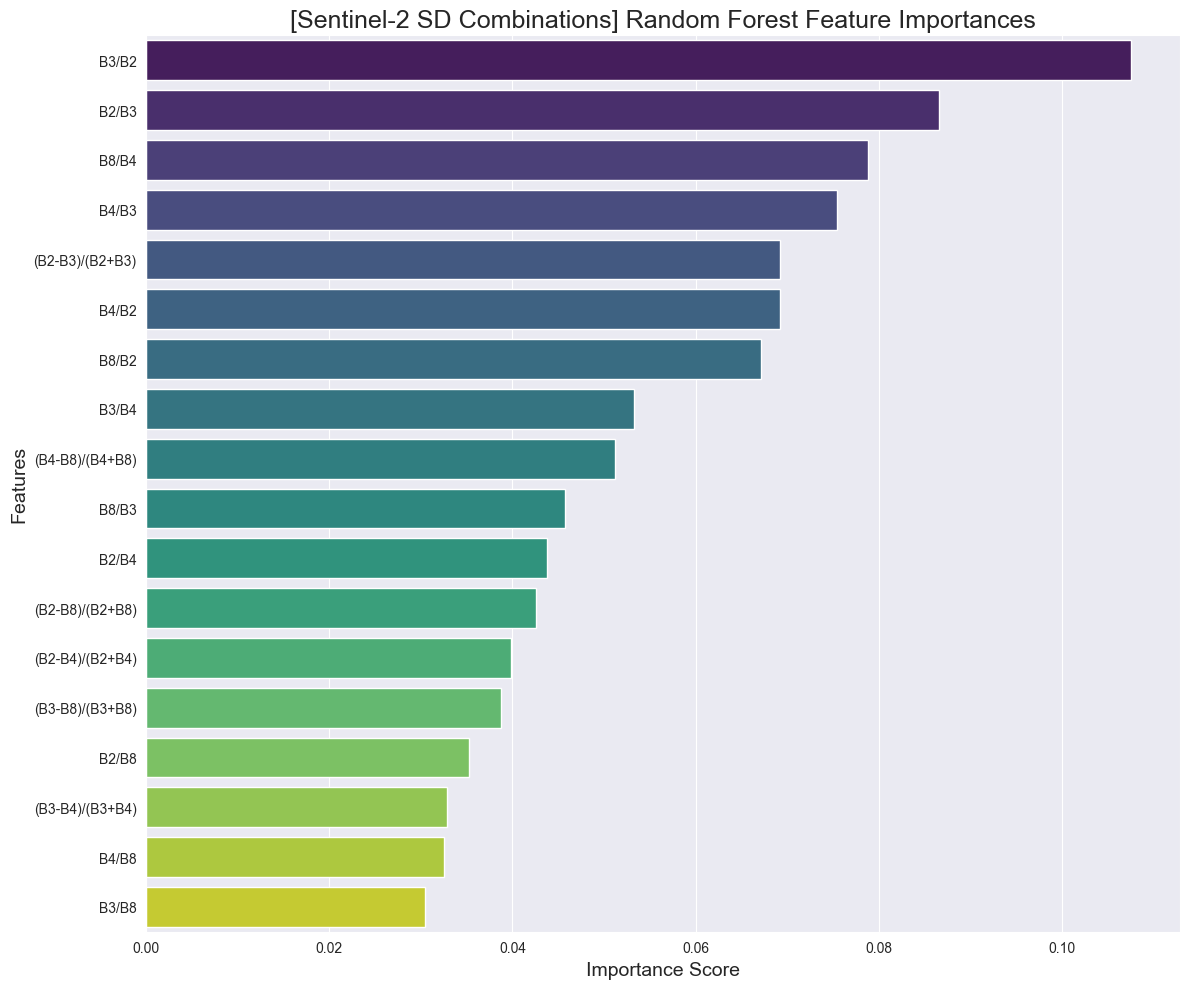

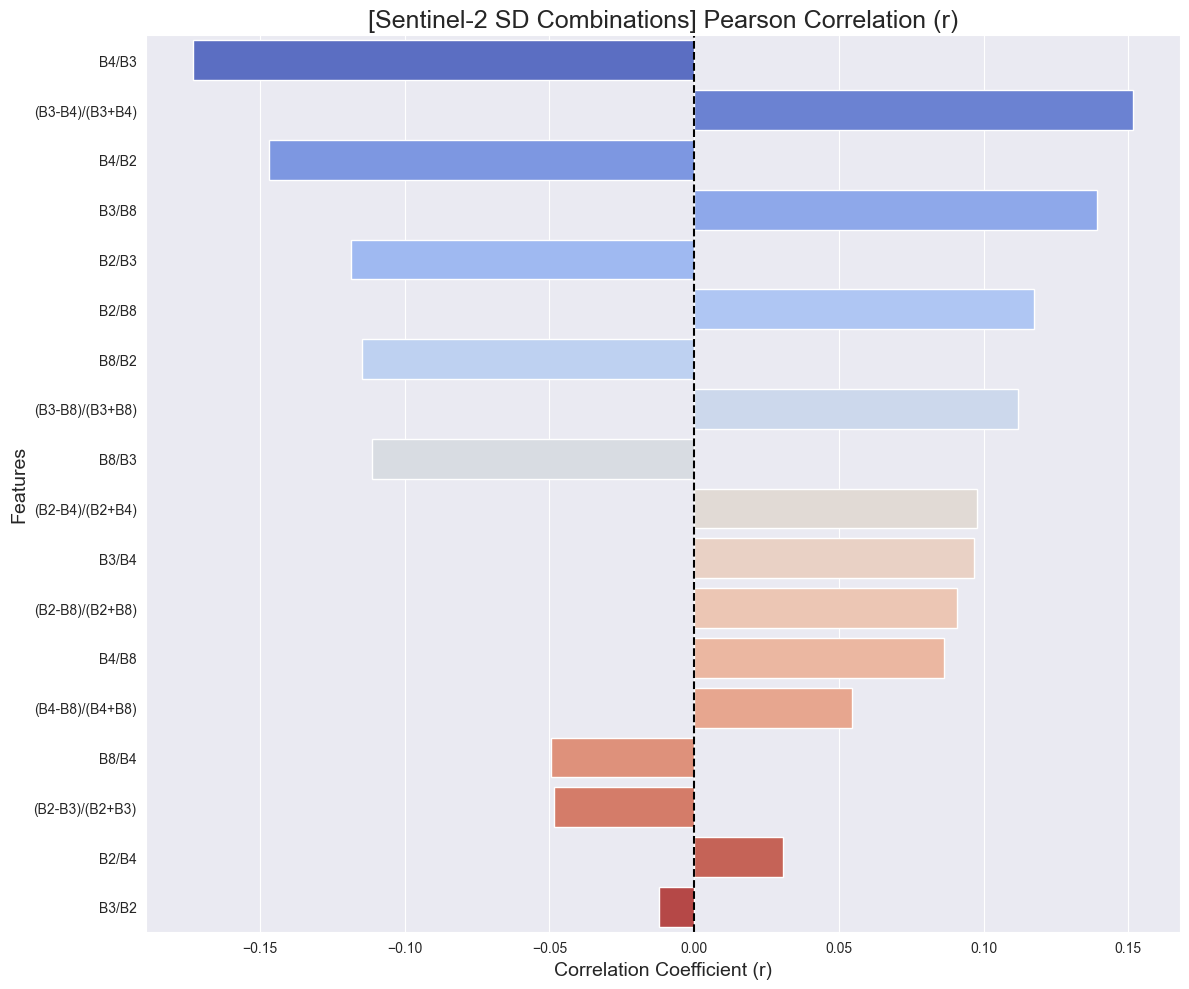

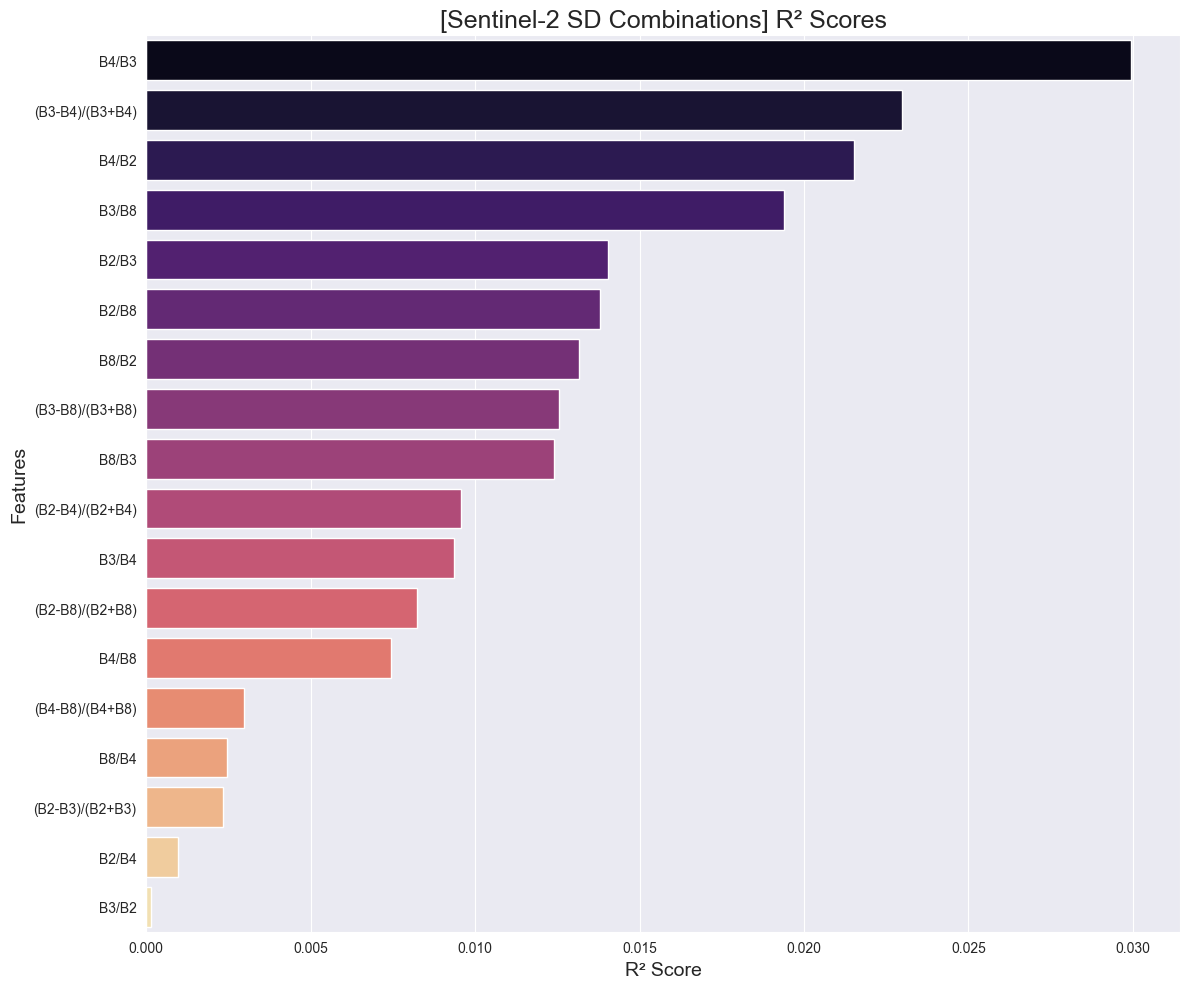

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# --- 1. Load Data ---
file_path = "Sentinel2_2024_Combinations(SD_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
feature_cols = [col for col in df.columns if '/' in col and 'Unnamed' not in col]

data = df[[target_col] + feature_cols].dropna()
X = data[feature_cols]
y = data[target_col]

# --- 3. Calculate Metrics ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = rf.feature_importances_

correlations = X.apply(lambda col: col.corr(y))
r2_scores = correlations ** 2

results_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': importances,
    'Correlation (r)': correlations,
    'R2_Score': r2_scores
}).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("      [SD] Complete Feature Metrics (Sorted by R2)        ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting (Separate, Full Width) ---

# Plot 1: RF Importance
plt.figure(figsize=(12, 10)) # Shorter figure for fewer combinations
rf_sorted = results_df.sort_values(by='RF_Importance', ascending=False)
sns.barplot(x='RF_Importance', y='Feature', data=rf_sorted, palette='viridis', hue='Feature', legend=False)
plt.title('[Sentinel-2 SD Combinations] Random Forest Feature Importances', fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Correlation
plt.figure(figsize=(12, 10))
corr_sorted = results_df.sort_values(by='Correlation (r)', key=abs, ascending=False)
sns.barplot(x='Correlation (r)', y='Feature', data=corr_sorted, palette='coolwarm', hue='Feature', legend=False)
plt.title('[Sentinel-2 SD Combinations] Pearson Correlation (r)', fontsize=18)
plt.xlabel('Correlation Coefficient (r)', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Plot 3: R2 Score
plt.figure(figsize=(12, 10))
r2_sorted = results_df.sort_values(by='R2_Score', ascending=False)
sns.barplot(x='R2_Score', y='Feature', data=r2_sorted, palette='magma', hue='Feature', legend=False)
plt.title('[Sentinel-2 SD Combinations] R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()